# Task 2: Compare NumPy and PyTorch MLP


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.utils import shuffle
from mlp_numpy import MLP as MLP_Numpy
from modules import Linear, CrossEntropy
from pytorch_mlp import MLP as MLP_PyTorch
from pytorch_train_mlp import accuracy


## Experiment 1: make_moons Dataset

### Data Generation


In [2]:
N_SAMPLES = 1000
NOISE = 0.1
TRAIN_RATIO = 0.8
RANDOM_STATE = 42

X, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=RANDOM_STATE)
X, y = shuffle(X, y, random_state=RANDOM_STATE)

split = int(len(X) * TRAIN_RATIO)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

n_classes = int(y.max()) + 1
y_train_onehot = np.eye(n_classes)[y_train]
y_test_onehot = np.eye(n_classes)[y_test]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}, Classes: {n_classes}")


Train size: 800, Test size: 200, Classes: 2


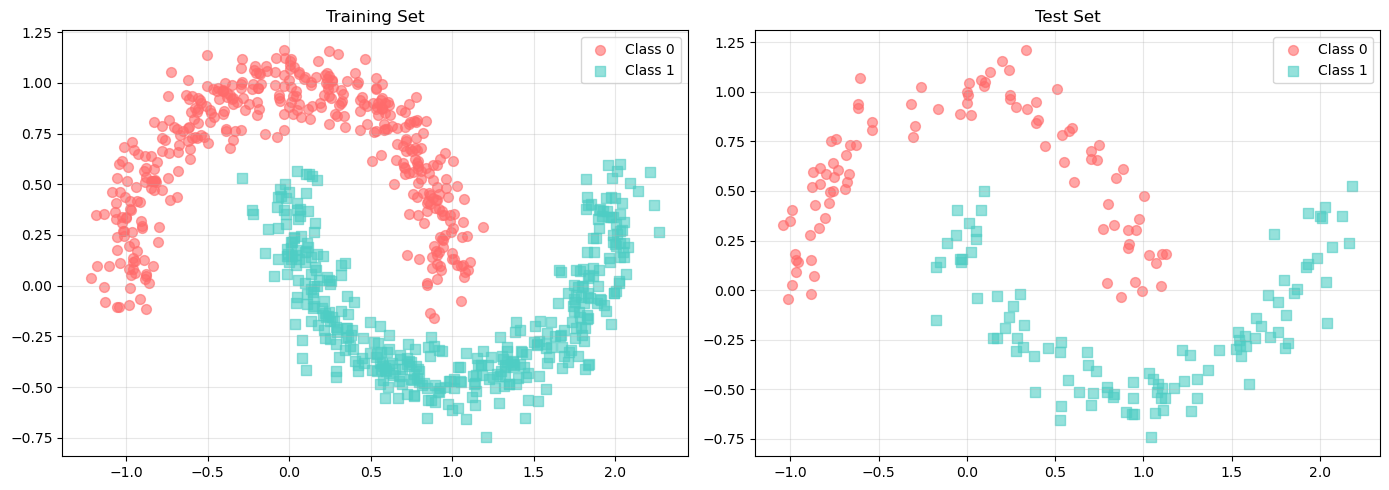

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4']
markers = ['o', 's']
for i in range(n_classes):
    mask = y_train == i
    ax1.scatter(X_train[mask, 0], X_train[mask, 1], c=colors[i], marker=markers[i], 
                label=f'Class {i}', alpha=0.6, s=50)
    mask = y_test == i
    ax2.scatter(X_test[mask, 0], X_test[mask, 1], c=colors[i], marker=markers[i], 
                label=f'Class {i}', alpha=0.6, s=50)
ax1.set_title('Training Set')
ax2.set_title('Test Set')
ax1.legend()
ax2.legend()
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Helper Functions


In [4]:
def get_batches(X, y, batch_size):
    n_samples = X.shape[0]
    if batch_size is None or batch_size >= n_samples:
        yield X, y
    else:
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            batch_indices = indices[start_idx:end_idx]
            yield X[batch_indices], y[batch_indices]

def parse_hidden_units(dnn_hidden_units):
    if dnn_hidden_units is None:
        return []
    s = dnn_hidden_units.strip()
    if not s:
        return []
    return [int(x) for x in s.split(',') if x.strip()]


## Train NumPy MLP


In [5]:
def train_numpy_mlp(X_train, y_train_onehot, X_test, y_test_onehot, 
                    n_inputs, n_classes, hidden_units, learning_rate, 
                    max_steps, eval_freq, batch_size=None, random_seed=42):
    np.random.seed(random_seed)
    model = MLP_Numpy(n_inputs=n_inputs, n_hidden=hidden_units, n_classes=n_classes)
    history = {'steps': [], 'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    for step in range(max_steps):
        epoch_losses = []
        for batch_X, batch_y in get_batches(X_train, y_train_onehot, batch_size):
            loss, probs = model.forward(batch_X, batch_y)
            epoch_losses.append(loss)
            model.backward(None, batch_y)
            for layer in model.layers:
                if isinstance(layer, Linear):
                    layer.params['weight'] -= learning_rate * layer.grads['weight']
                    layer.params['bias'] -= learning_rate * layer.grads['bias']
        
        if step % eval_freq == 0 or step == max_steps - 1:
            train_loss, train_probs = model.forward(X_train, y_train_onehot)
            train_acc = accuracy(train_probs, y_train_onehot) * 100
            test_probs = model.forward(X_test)
            test_ce = CrossEntropy()
            test_loss = test_ce.forward(test_probs, y_test_onehot)
            test_acc = accuracy(test_probs, y_test_onehot) * 100
            
            history['steps'].append(step)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc)
            
            print(f"Step: {step:4d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}% | "
                  f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:5.2f}%")
    
    return model, history


## Train PyTorch MLP


In [6]:
def train_pytorch_mlp(X_train, y_train_onehot, X_test, y_test_onehot,
                      n_inputs, n_classes, hidden_units, learning_rate,
                      max_steps, eval_freq, batch_size=None, random_seed=42):
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(random_seed)
    
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.LongTensor(np.argmax(y_train_onehot, axis=1))
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.LongTensor(np.argmax(y_test_onehot, axis=1))
    
    if batch_size is None:
        batch_size = len(X_train)
    train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    model = MLP_PyTorch(n_inputs=n_inputs, n_hidden=hidden_units, n_classes=n_classes)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    history = {'steps': [], 'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    for epoch in range(max_steps):
        model.train()
        for i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            if i % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_outputs = model(X_train_tensor)
                    train_loss = criterion(train_outputs, y_train_tensor).item()
                    train_acc = accuracy(train_outputs.numpy(), y_train_onehot) * 100
                    
                    test_outputs = model(X_test_tensor)
                    test_loss = criterion(test_outputs, y_test_tensor).item()
                    test_acc = accuracy(test_outputs.numpy(), y_test_onehot) * 100
        
        if epoch % eval_freq == 0 or epoch == max_steps - 1:
            model.eval()
            with torch.no_grad():
                train_outputs = model(X_train_tensor)
                train_loss = criterion(train_outputs, y_train_tensor).item()
                train_acc = accuracy(train_outputs.numpy(), y_train_onehot) * 100
                
                test_outputs = model(X_test_tensor)
                test_loss = criterion(test_outputs, y_test_tensor).item()
                test_acc = accuracy(test_outputs.numpy(), y_test_onehot) * 100
                
                history['steps'].append(epoch)
                history['train_loss'].append(train_loss)
                history['train_acc'].append(train_acc)
                history['test_loss'].append(test_loss)
                history['test_acc'].append(test_acc)
                
                print(f"Step: {epoch:4d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}% | "
                      f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:5.2f}%")
    
    return model, history


## Training Parameters


In [7]:
DNN_HIDDEN_UNITS = '20'
LEARNING_RATE = 1e-2
MAX_STEPS = 1500
EVAL_FREQ = 10
BATCH_SIZE = None
RANDOM_SEED = 42

hidden_units = parse_hidden_units(DNN_HIDDEN_UNITS)
n_inputs = X_train.shape[1]

print(f"Hidden units: {hidden_units}, LR: {LEARNING_RATE}, Steps: {MAX_STEPS}, Batch: {BATCH_SIZE}")


Hidden units: [20], LR: 0.01, Steps: 1500, Batch: None


## Train Models


In [8]:
print("Training NumPy MLP...")
model_numpy, history_numpy = train_numpy_mlp(
    X_train, y_train_onehot, X_test, y_test_onehot,
    n_inputs=n_inputs, n_classes=n_classes, hidden_units=hidden_units,
    learning_rate=LEARNING_RATE, max_steps=MAX_STEPS, eval_freq=EVAL_FREQ,
    batch_size=BATCH_SIZE, random_seed=RANDOM_SEED
)


Training NumPy MLP...
Step:    0 | Train Loss: 0.6929 | Train Acc: 81.50% | Test Loss: 0.6929 | Test Acc: 82.00%
Step:   10 | Train Loss: 0.6929 | Train Acc: 72.50% | Test Loss: 0.6929 | Test Acc: 77.50%
Step:   20 | Train Loss: 0.6929 | Train Acc: 50.50% | Test Loss: 0.6929 | Test Acc: 48.00%
Step:   30 | Train Loss: 0.6928 | Train Acc: 50.50% | Test Loss: 0.6929 | Test Acc: 48.00%
Step:   40 | Train Loss: 0.6928 | Train Acc: 50.50% | Test Loss: 0.6929 | Test Acc: 48.00%
Step:   50 | Train Loss: 0.6928 | Train Acc: 50.50% | Test Loss: 0.6928 | Test Acc: 48.00%
Step:   60 | Train Loss: 0.6927 | Train Acc: 50.50% | Test Loss: 0.6928 | Test Acc: 48.00%
Step:   70 | Train Loss: 0.6927 | Train Acc: 50.50% | Test Loss: 0.6928 | Test Acc: 48.00%
Step:   80 | Train Loss: 0.6926 | Train Acc: 50.50% | Test Loss: 0.6928 | Test Acc: 48.00%
Step:   90 | Train Loss: 0.6926 | Train Acc: 50.50% | Test Loss: 0.6928 | Test Acc: 48.00%
Step:  100 | Train Loss: 0.6926 | Train Acc: 50.50% | Test Loss: 0.6

In [9]:
print("Training PyTorch MLP...")
model_pytorch, history_pytorch = train_pytorch_mlp(
    X_train, y_train_onehot, X_test, y_test_onehot,
    n_inputs=n_inputs, n_classes=n_classes, hidden_units=hidden_units,
    learning_rate=LEARNING_RATE, max_steps=MAX_STEPS, eval_freq=EVAL_FREQ,
    batch_size=BATCH_SIZE, random_seed=RANDOM_SEED
)


Training PyTorch MLP...
Step:    0 | Train Loss: 0.6851 | Train Acc: 72.62% | Test Loss: 0.6840 | Test Acc: 73.50%
Step:   10 | Train Loss: 0.6671 | Train Acc: 78.88% | Test Loss: 0.6644 | Test Acc: 79.50%
Step:   20 | Train Loss: 0.6522 | Train Acc: 74.38% | Test Loss: 0.6477 | Test Acc: 75.50%
Step:   30 | Train Loss: 0.6413 | Train Acc: 72.88% | Test Loss: 0.6350 | Test Acc: 74.00%
Step:   40 | Train Loss: 0.6325 | Train Acc: 72.00% | Test Loss: 0.6248 | Test Acc: 73.50%
Step:   50 | Train Loss: 0.6251 | Train Acc: 71.50% | Test Loss: 0.6163 | Test Acc: 73.50%
Step:   60 | Train Loss: 0.6188 | Train Acc: 71.50% | Test Loss: 0.6090 | Test Acc: 74.50%
Step:   70 | Train Loss: 0.6133 | Train Acc: 72.00% | Test Loss: 0.6026 | Test Acc: 75.00%
Step:   80 | Train Loss: 0.6084 | Train Acc: 72.75% | Test Loss: 0.5970 | Test Acc: 75.00%
Step:   90 | Train Loss: 0.6041 | Train Acc: 73.75% | Test Loss: 0.5921 | Test Acc: 76.00%
Step:  100 | Train Loss: 0.6002 | Train Acc: 73.75% | Test Loss: 0

## Results Comparison


In [10]:
print("NumPy MLP - Train Acc: {:.2f}%, Test Acc: {:.2f}%".format(
    history_numpy['train_acc'][-1], history_numpy['test_acc'][-1]))
print("PyTorch MLP - Train Acc: {:.2f}%, Test Acc: {:.2f}%".format(
    history_pytorch['train_acc'][-1], history_pytorch['test_acc'][-1]))
print("Difference - Train: {:.2f}%, Test: {:.2f}%".format(
    abs(history_numpy['train_acc'][-1] - history_pytorch['train_acc'][-1]),
    abs(history_numpy['test_acc'][-1] - history_pytorch['test_acc'][-1])))


NumPy MLP - Train Acc: 84.00%, Test Acc: 83.50%
PyTorch MLP - Train Acc: 86.25%, Test Acc: 86.50%
Difference - Train: 2.25%, Test: 3.00%


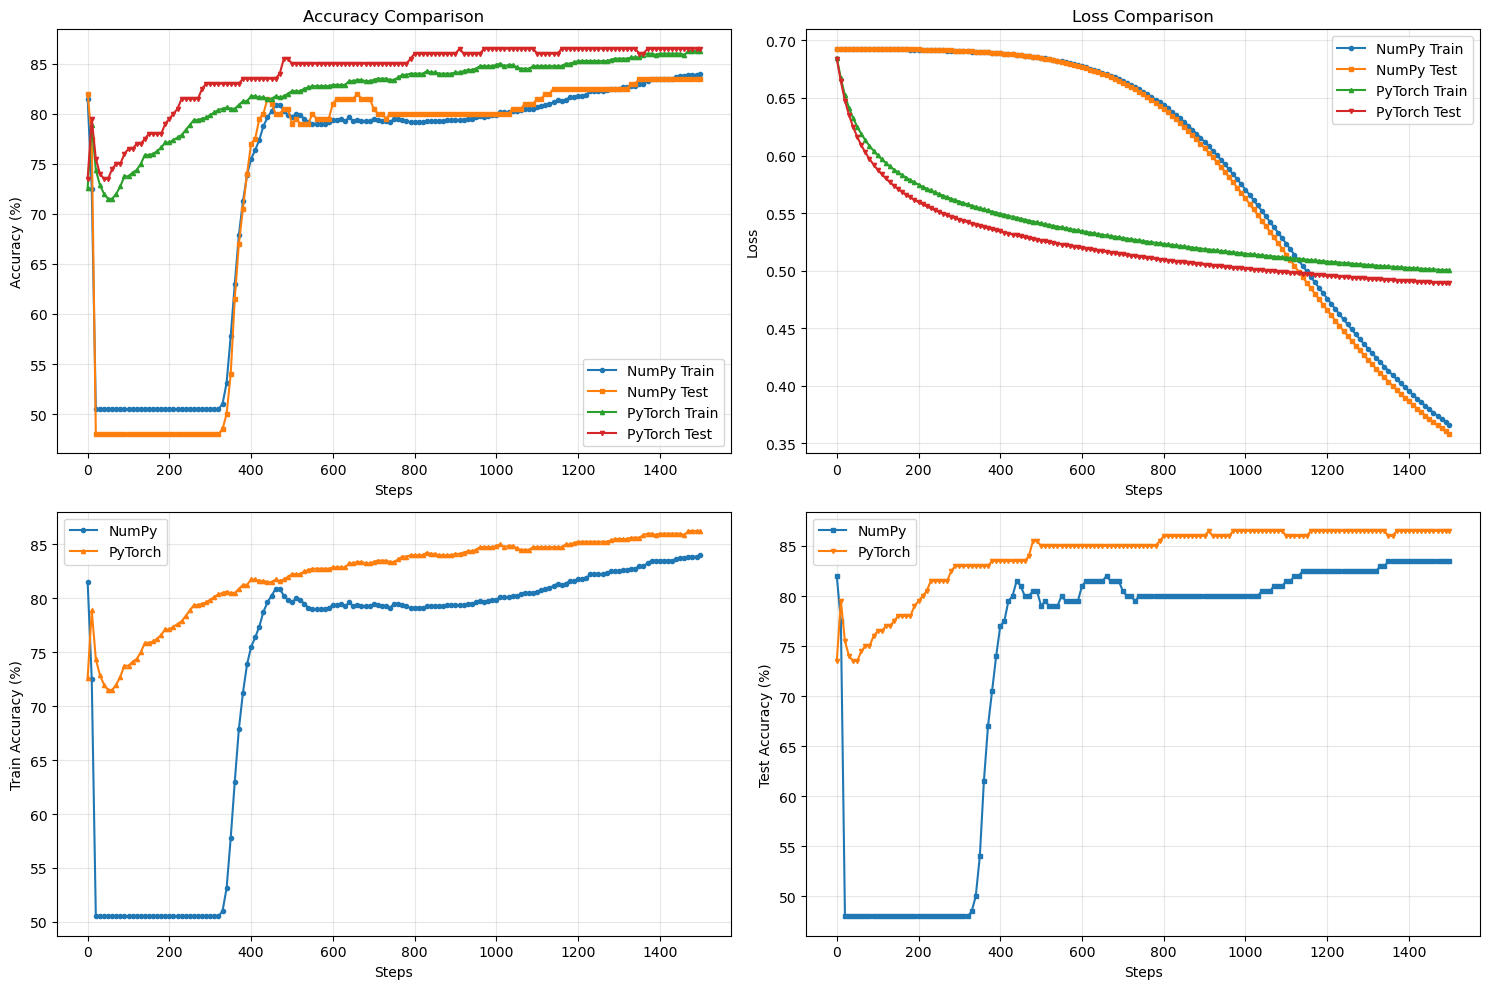

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history_numpy['steps'], history_numpy['train_acc'], 'o-', label='NumPy Train', markersize=3)
axes[0, 0].plot(history_numpy['steps'], history_numpy['test_acc'], 's-', label='NumPy Test', markersize=3)
axes[0, 0].plot(history_pytorch['steps'], history_pytorch['train_acc'], '^-', label='PyTorch Train', markersize=3)
axes[0, 0].plot(history_pytorch['steps'], history_pytorch['test_acc'], 'v-', label='PyTorch Test', markersize=3)
axes[0, 0].set_xlabel('Steps')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Accuracy Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_numpy['steps'], history_numpy['train_loss'], 'o-', label='NumPy Train', markersize=3)
axes[0, 1].plot(history_numpy['steps'], history_numpy['test_loss'], 's-', label='NumPy Test', markersize=3)
axes[0, 1].plot(history_pytorch['steps'], history_pytorch['train_loss'], '^-', label='PyTorch Train', markersize=3)
axes[0, 1].plot(history_pytorch['steps'], history_pytorch['test_loss'], 'v-', label='PyTorch Test', markersize=3)
axes[0, 1].set_xlabel('Steps')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history_numpy['steps'], history_numpy['train_acc'], 'o-', label='NumPy', markersize=3)
axes[1, 0].plot(history_pytorch['steps'], history_pytorch['train_acc'], '^-', label='PyTorch', markersize=3)
axes[1, 0].set_xlabel('Steps')
axes[1, 0].set_ylabel('Train Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_numpy['steps'], history_numpy['test_acc'], 's-', label='NumPy', markersize=3)
axes[1, 1].plot(history_pytorch['steps'], history_pytorch['test_acc'], 'v-', label='PyTorch', markersize=3)
axes[1, 1].set_xlabel('Steps')
axes[1, 1].set_ylabel('Test Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Decision Boundary Visualization


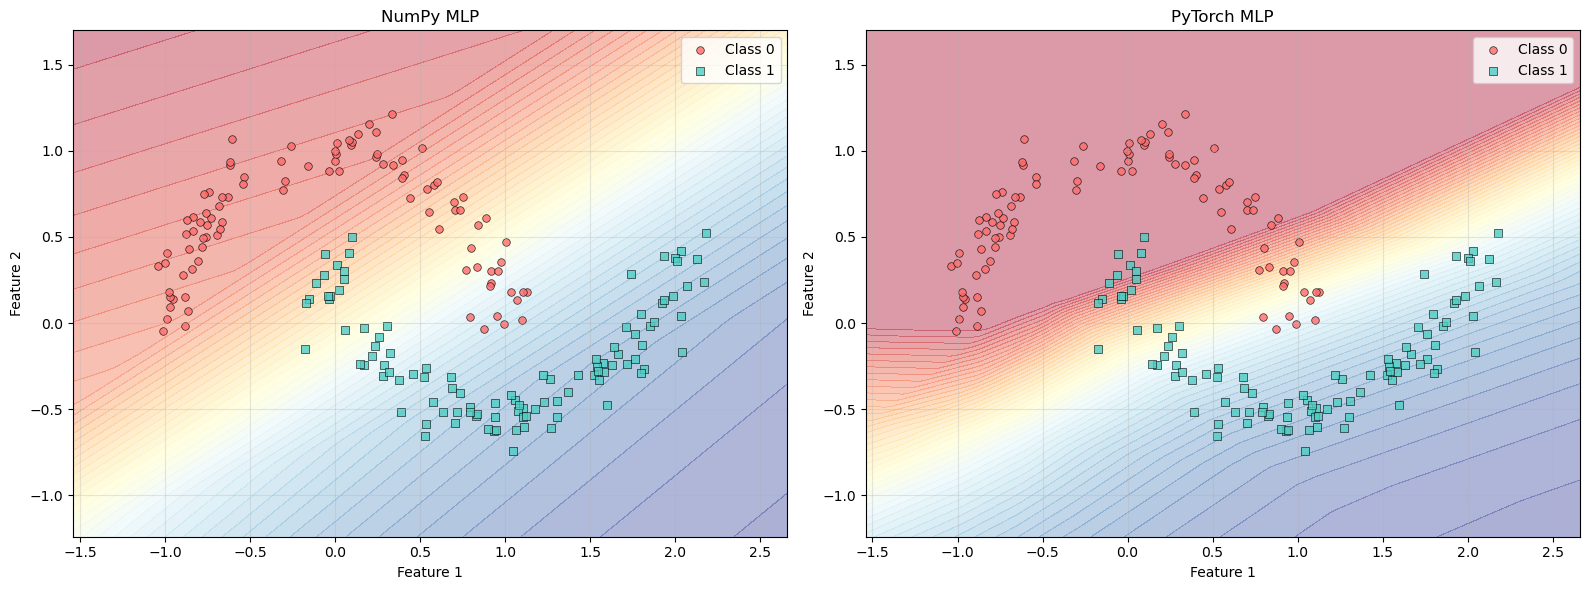

In [12]:
def plot_decision_boundary(model, X, y, title, is_pytorch=False):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    if is_pytorch:
        model.eval()
        with torch.no_grad():
            grid_tensor = torch.FloatTensor(grid_points)
            Z = model(grid_tensor)
            Z = torch.softmax(Z, dim=1)
            Z = Z[:, 1].detach().cpu().numpy()
    else:
        Z = model.forward(grid_points)
        Z = Z[:, 1]
    
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=50, alpha=0.4, cmap=plt.cm.RdYlBu)
    colors = ['#FF6B6B', '#4ECDC4']
    markers = ['o', 's']
    for i in range(n_classes):
        mask = y == i
        plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], marker=markers[i], 
                   label=f'Class {i}', alpha=0.8, s=30, edgecolors='black', linewidth=0.5)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_decision_boundary(model_numpy, X_test, y_test, 'NumPy MLP', is_pytorch=False)
plt.sca(ax2)
plot_decision_boundary(model_pytorch, X_test, y_test, 'PyTorch MLP', is_pytorch=True)
plt.tight_layout()
plt.show()


## Experiment 2: make_circles Dataset


Train size: 800, Test size: 200, Classes: 2


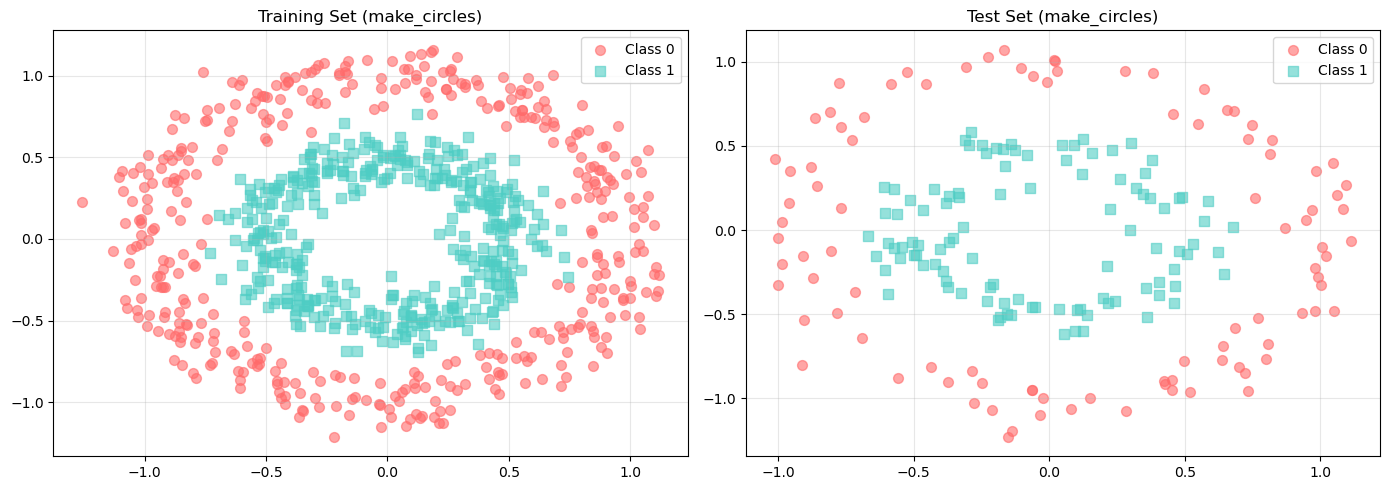

In [14]:
from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(n_samples=N_SAMPLES, noise=0.1, factor=0.5, random_state=RANDOM_STATE)
X_circles, y_circles = shuffle(X_circles, y_circles, random_state=RANDOM_STATE)

split = int(len(X_circles) * TRAIN_RATIO)
X_train_circles, y_train_circles = X_circles[:split], y_circles[:split]
X_test_circles, y_test_circles = X_circles[split:], y_circles[split:]

n_classes_circles = int(y_circles.max()) + 1
y_train_circles_onehot = np.eye(n_classes_circles)[y_train_circles]
y_test_circles_onehot = np.eye(n_classes_circles)[y_test_circles]

print(f"Train size: {X_train_circles.shape[0]}, Test size: {X_test_circles.shape[0]}, Classes: {n_classes_circles}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4']
markers = ['o', 's']
for i in range(n_classes_circles):
    mask = y_train_circles == i
    ax1.scatter(X_train_circles[mask, 0], X_train_circles[mask, 1], c=colors[i], marker=markers[i], 
                label=f'Class {i}', alpha=0.6, s=50)
    mask = y_test_circles == i
    ax2.scatter(X_test_circles[mask, 0], X_test_circles[mask, 1], c=colors[i], marker=markers[i], 
                label=f'Class {i}', alpha=0.6, s=50)
ax1.set_title('Training Set (make_circles)')
ax2.set_title('Test Set (make_circles)')
ax1.legend()
ax2.legend()
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Train Models on make_circles


In [15]:
n_inputs_circles = X_train_circles.shape[1]

print("Training NumPy MLP on make_circles...")
model_numpy_circles, history_numpy_circles = train_numpy_mlp(
    X_train_circles, y_train_circles_onehot, X_test_circles, y_test_circles_onehot,
    n_inputs=n_inputs_circles, n_classes=n_classes_circles, hidden_units=hidden_units,
    learning_rate=LEARNING_RATE, max_steps=MAX_STEPS, eval_freq=EVAL_FREQ,
    batch_size=BATCH_SIZE, random_seed=RANDOM_SEED
)


Training NumPy MLP on make_circles...
Step:    0 | Train Loss: 0.6932 | Train Acc: 47.88% | Test Loss: 0.6932 | Test Acc: 43.00%
Step:   10 | Train Loss: 0.6932 | Train Acc: 43.38% | Test Loss: 0.6932 | Test Acc: 35.00%
Step:   20 | Train Loss: 0.6932 | Train Acc: 50.50% | Test Loss: 0.6933 | Test Acc: 48.00%
Step:   30 | Train Loss: 0.6932 | Train Acc: 50.50% | Test Loss: 0.6933 | Test Acc: 48.00%
Step:   40 | Train Loss: 0.6932 | Train Acc: 50.50% | Test Loss: 0.6933 | Test Acc: 48.00%
Step:   50 | Train Loss: 0.6932 | Train Acc: 50.50% | Test Loss: 0.6933 | Test Acc: 48.00%
Step:   60 | Train Loss: 0.6932 | Train Acc: 50.50% | Test Loss: 0.6933 | Test Acc: 48.00%
Step:   70 | Train Loss: 0.6932 | Train Acc: 50.50% | Test Loss: 0.6933 | Test Acc: 48.00%
Step:   80 | Train Loss: 0.6931 | Train Acc: 50.50% | Test Loss: 0.6933 | Test Acc: 48.00%
Step:   90 | Train Loss: 0.6931 | Train Acc: 50.50% | Test Loss: 0.6934 | Test Acc: 48.00%
Step:  100 | Train Loss: 0.6931 | Train Acc: 50.50% 

In [16]:
print("Training PyTorch MLP on make_circles...")
model_pytorch_circles, history_pytorch_circles = train_pytorch_mlp(
    X_train_circles, y_train_circles_onehot, X_test_circles, y_test_circles_onehot,
    n_inputs=n_inputs_circles, n_classes=n_classes_circles, hidden_units=hidden_units,
    learning_rate=LEARNING_RATE, max_steps=MAX_STEPS, eval_freq=EVAL_FREQ,
    batch_size=BATCH_SIZE, random_seed=RANDOM_SEED
)


Training PyTorch MLP on make_circles...
Step:    0 | Train Loss: 0.6904 | Train Acc: 63.38% | Test Loss: 0.6880 | Test Acc: 62.50%
Step:   10 | Train Loss: 0.6887 | Train Acc: 64.12% | Test Loss: 0.6861 | Test Acc: 63.50%
Step:   20 | Train Loss: 0.6869 | Train Acc: 64.50% | Test Loss: 0.6842 | Test Acc: 63.50%
Step:   30 | Train Loss: 0.6854 | Train Acc: 63.12% | Test Loss: 0.6825 | Test Acc: 62.00%
Step:   40 | Train Loss: 0.6841 | Train Acc: 61.25% | Test Loss: 0.6810 | Test Acc: 62.00%
Step:   50 | Train Loss: 0.6831 | Train Acc: 60.75% | Test Loss: 0.6796 | Test Acc: 61.00%
Step:   60 | Train Loss: 0.6822 | Train Acc: 59.62% | Test Loss: 0.6784 | Test Acc: 61.00%
Step:   70 | Train Loss: 0.6815 | Train Acc: 58.75% | Test Loss: 0.6773 | Test Acc: 59.50%
Step:   80 | Train Loss: 0.6808 | Train Acc: 57.38% | Test Loss: 0.6764 | Test Acc: 58.00%
Step:   90 | Train Loss: 0.6802 | Train Acc: 57.12% | Test Loss: 0.6755 | Test Acc: 58.00%
Step:  100 | Train Loss: 0.6796 | Train Acc: 56.62

## Results Comparison (make_circles)


In [17]:
print("NumPy MLP - Train Acc: {:.2f}%, Test Acc: {:.2f}%".format(
    history_numpy_circles['train_acc'][-1], history_numpy_circles['test_acc'][-1]))
print("PyTorch MLP - Train Acc: {:.2f}%, Test Acc: {:.2f}%".format(
    history_pytorch_circles['train_acc'][-1], history_pytorch_circles['test_acc'][-1]))
print("Difference - Train: {:.2f}%, Test: {:.2f}%".format(
    abs(history_numpy_circles['train_acc'][-1] - history_pytorch_circles['train_acc'][-1]),
    abs(history_numpy_circles['test_acc'][-1] - history_pytorch_circles['test_acc'][-1])))


NumPy MLP - Train Acc: 50.50%, Test Acc: 48.00%
PyTorch MLP - Train Acc: 62.38%, Test Acc: 66.50%
Difference - Train: 11.88%, Test: 18.50%


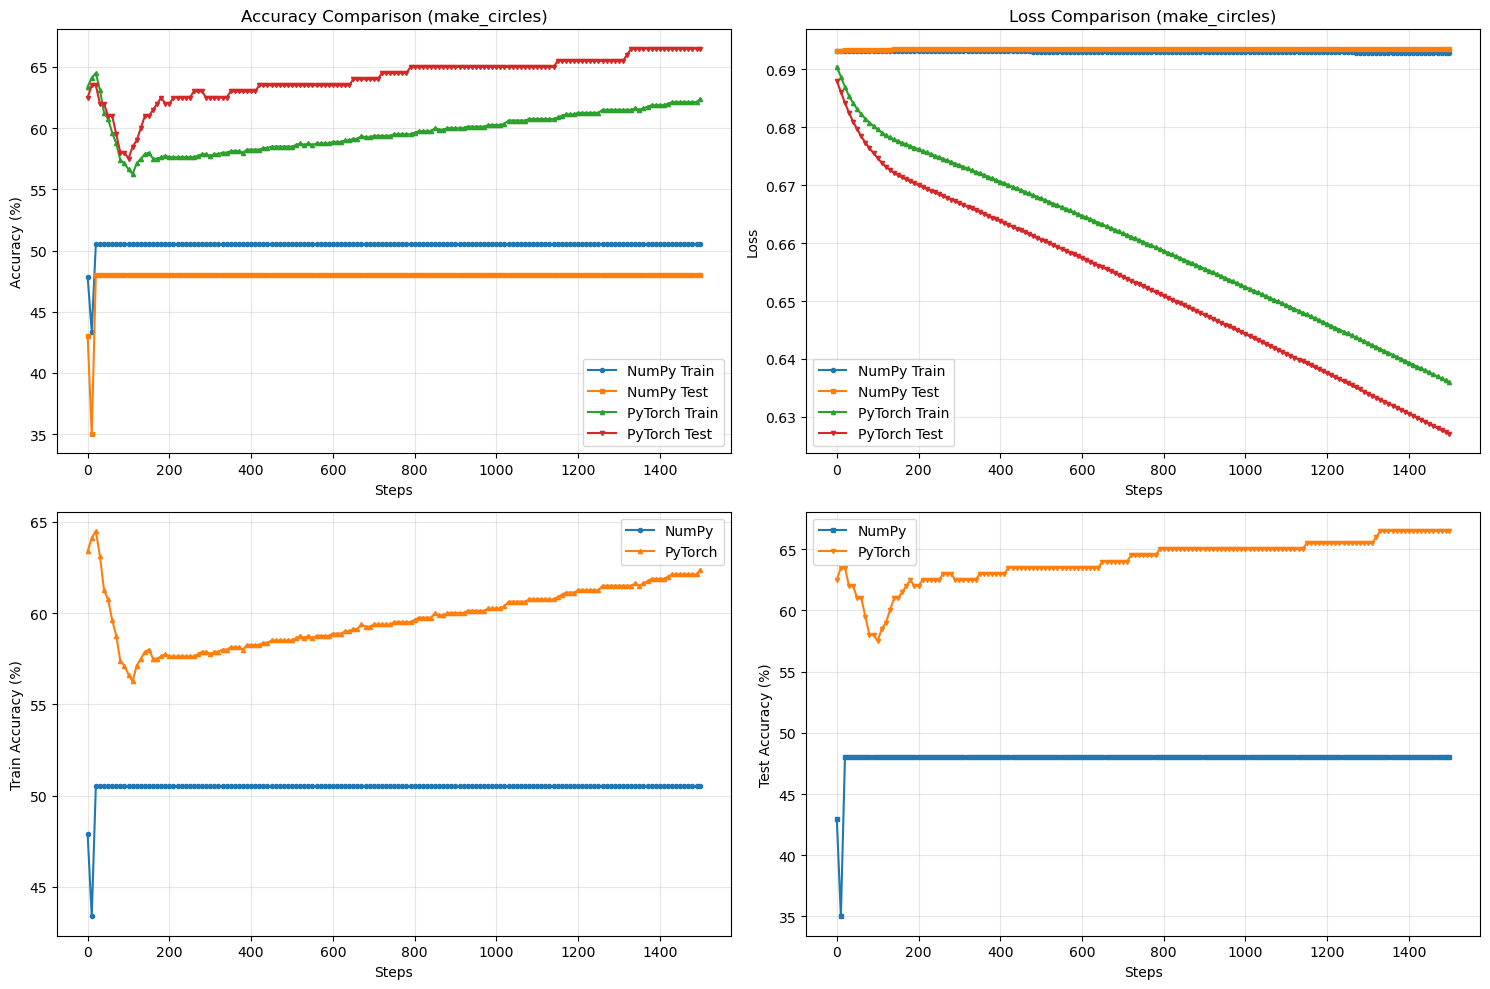

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history_numpy_circles['steps'], history_numpy_circles['train_acc'], 'o-', label='NumPy Train', markersize=3)
axes[0, 0].plot(history_numpy_circles['steps'], history_numpy_circles['test_acc'], 's-', label='NumPy Test', markersize=3)
axes[0, 0].plot(history_pytorch_circles['steps'], history_pytorch_circles['train_acc'], '^-', label='PyTorch Train', markersize=3)
axes[0, 0].plot(history_pytorch_circles['steps'], history_pytorch_circles['test_acc'], 'v-', label='PyTorch Test', markersize=3)
axes[0, 0].set_xlabel('Steps')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Accuracy Comparison (make_circles)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_numpy_circles['steps'], history_numpy_circles['train_loss'], 'o-', label='NumPy Train', markersize=3)
axes[0, 1].plot(history_numpy_circles['steps'], history_numpy_circles['test_loss'], 's-', label='NumPy Test', markersize=3)
axes[0, 1].plot(history_pytorch_circles['steps'], history_pytorch_circles['train_loss'], '^-', label='PyTorch Train', markersize=3)
axes[0, 1].plot(history_pytorch_circles['steps'], history_pytorch_circles['test_loss'], 'v-', label='PyTorch Test', markersize=3)
axes[0, 1].set_xlabel('Steps')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Loss Comparison (make_circles)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history_numpy_circles['steps'], history_numpy_circles['train_acc'], 'o-', label='NumPy', markersize=3)
axes[1, 0].plot(history_pytorch_circles['steps'], history_pytorch_circles['train_acc'], '^-', label='PyTorch', markersize=3)
axes[1, 0].set_xlabel('Steps')
axes[1, 0].set_ylabel('Train Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_numpy_circles['steps'], history_numpy_circles['test_acc'], 's-', label='NumPy', markersize=3)
axes[1, 1].plot(history_pytorch_circles['steps'], history_pytorch_circles['test_acc'], 'v-', label='PyTorch', markersize=3)
axes[1, 1].set_xlabel('Steps')
axes[1, 1].set_ylabel('Test Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Decision Boundary Visualization (make_circles)


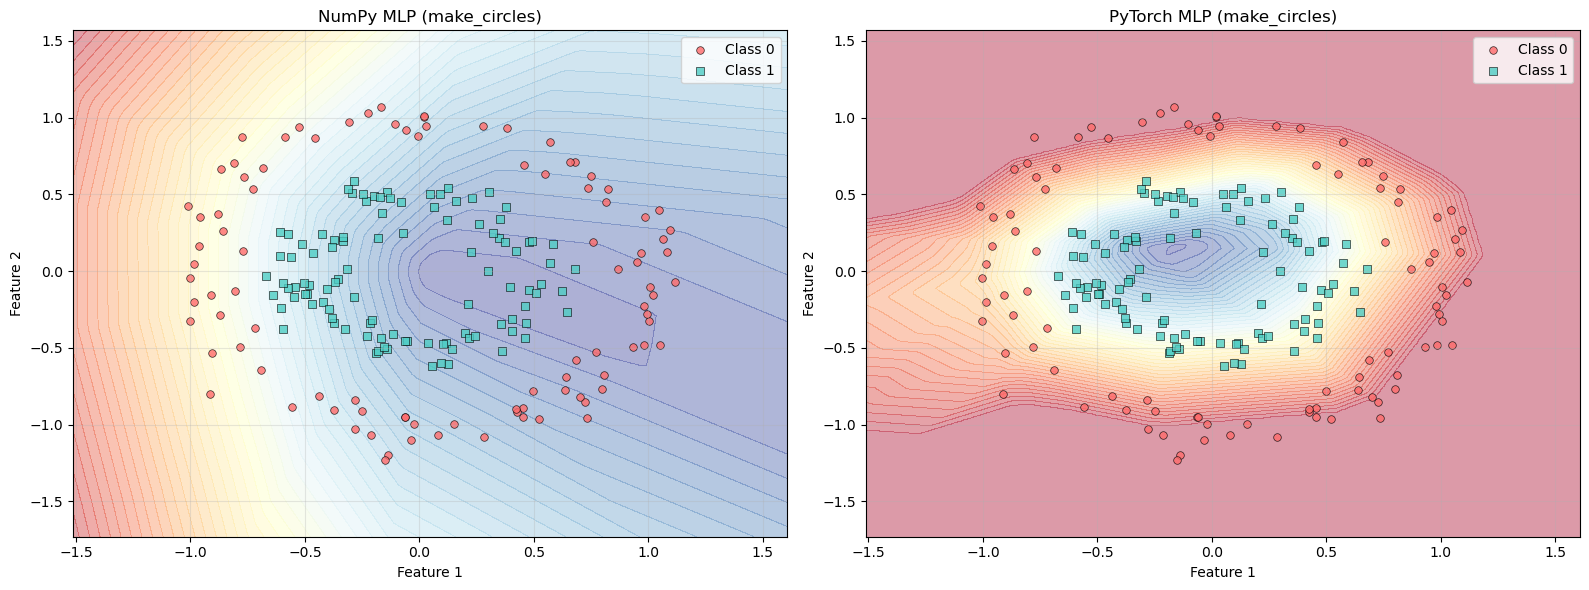

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_decision_boundary(model_numpy_circles, X_test_circles, y_test_circles, 'NumPy MLP (make_circles)', is_pytorch=False)
plt.sca(ax2)
plot_decision_boundary(model_pytorch_circles, X_test_circles, y_test_circles, 'PyTorch MLP (make_circles)', is_pytorch=True)
plt.tight_layout()
plt.show()
